<a href="https://colab.research.google.com/github/michamettler/zhaw-xai/blob/main/XAI_Lab2_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# XAI Lab: Visual explanations


Members: Micha Mettler (mettlmi1)

Complete the coding exercises below.

The dataset we will be using is **DermaMNIST**, a subset of the MedMNIST benchmark derived from the HAM10000 collection of dermatoscopic images. It contains skin lesion images across 7 diagnostic categories (e.g., melanoma, nevus, basal cell carcinoma). Each image is a 3-channel RGB photo of a skin lesion, resized to 28×28 pixels in the original benchmark (we upscale to 128×128 here). We will train a CNN classifier on this dataset and apply various saliency-based attribution methods to explain its predictions.

In [24]:
!pip install medmnist
!pip install captum --no-deps
!pip install opencv

ERROR: Could not find a version that satisfies the requirement opencv (from versions: none)
ERROR: No matching distribution found for opencv


In [25]:
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import torch.nn.functional as F

import medmnist
from medmnist import INFO
from medmnist.dataset import DermaMNIST

from captum.attr import Saliency, NoiseTunnel, LayerGradCam, LayerAttribution, LRP
import cv2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [26]:
data_flag = 'dermamnist'
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

# Transform (resize - optional)
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# Load datasets
train_dataset = DataClass(split='train', transform=transform, download=True, size=128)
val_dataset   = DataClass(split='val',   transform=transform, download=True, size=128)
test_dataset  = DataClass(split='test',  transform=transform, download=True, size=128)

# Build loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)


In [27]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
            )

        self.conv1 = block(3, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = block(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.conv3 = block(64, 128)

        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.pool1(x)
        x = self.conv2(x)
        x = self.pool2(x)
        x = self.conv3(x)
        x_gap = self.gap(x).view(x.size(0), -1)
        out = self.fc(x_gap)
        return out

model = SimpleCNN(num_classes=7).to(device)

In [28]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for imgs, lbls in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        imgs, lbls = imgs.to(device), lbls.squeeze().long().to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch {epoch+1}, Train Loss: {avg_loss:.4f}")

Epoch 1: 100%|██████████| 110/110 [00:21<00:00,  5.10it/s]


Epoch 1, Train Loss: 0.9845


Epoch 2: 100%|██████████| 110/110 [00:18<00:00,  5.94it/s]


Epoch 2, Train Loss: 0.8492


Epoch 3: 100%|██████████| 110/110 [00:17<00:00,  6.16it/s]


...

Epoch 8, Train Loss: 0.7325


Epoch 9: 100%|██████████| 110/110 [00:17<00:00,  6.15it/s]


Epoch 9, Train Loss: 0.7226


Epoch 10: 100%|██████████| 110/110 [00:18<00:00,  6.07it/s]

Epoch 10, Train Loss: 0.7203


In [29]:
model.eval()

seed = 43
torch.manual_seed(seed)

# Pick a random image from validation loader
val_iter = iter(val_loader)
img_batch, label_batch = next(val_iter)
rand_idx = torch.randint(0, img_batch.size(0), (1,)).item()
img, label = img_batch[rand_idx:rand_idx+1].to(device), label_batch[rand_idx].item()

print(f"Selected image index: {rand_idx}, label: {label}")

Selected image index: 63, label: 2


We have defined a model, trained it on the data for a few epochs and picked one image from the validation set.
- Compute the following attribution maps for the selected image:
  - **Task (1.5 point)** Vanilla Gradients
  - **Task (2 points)** SmoothGrad
  - **Task (2 points)** GradCAM
  - **Task (2 points)** LRP

  (Optional: Try to implement some of the methods above without using Captum).

- **Task (0.5 point)** Visualize the original image and all attribution maps side-by-side in a single figure
- **Task (1 point)** Identify two missclassified samples and compute all 4 attribution maps for each.
- **Task (1 point)** Quantify how much each attrbution method focuses on the object vs background:
  - For a selected image, define a central mask (e.g., central 50% of the image) as the “object region”.
  - For each attribution map compute the fraction of saliency inside the object region

### Coding tasks:

Compute the following attribution maps for the selected image:
- **Task (1.5 point)** Vanilla Gradients

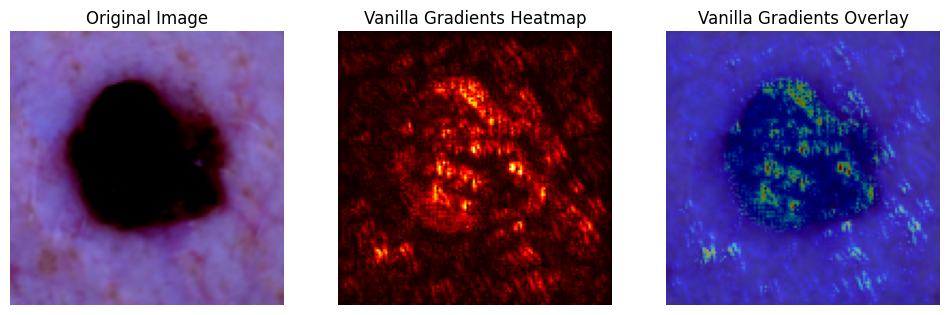

In [30]:
# Your solution here ...

# enable gradient tracking for gradient-based attribution methods
img.requires_grad = True

# helper function to plot all 3: original, heatmap, overlay of the map on the original
def show_heatmap(image, heatmap, title):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(image.detach().cpu().squeeze().permute(1, 2, 0))
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap, cmap='hot')
    plt.title(f"{title} Heatmap")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(image.detach().cpu().squeeze().permute(1, 2, 0))
    plt.imshow(heatmap, cmap='jet', alpha=0.5)
    plt.title(f"{title} Overlay")
    plt.axis('off')

    plt.show()

saliency = Saliency(model)
vanilla_attr = saliency.attribute(img, target=label)
vanilla_attr = vanilla_attr.squeeze().detach().cpu().numpy().max(axis=0)

show_heatmap(img, vanilla_attr, "Vanilla Gradients")

- **Task (2 points)** SmoothGrad

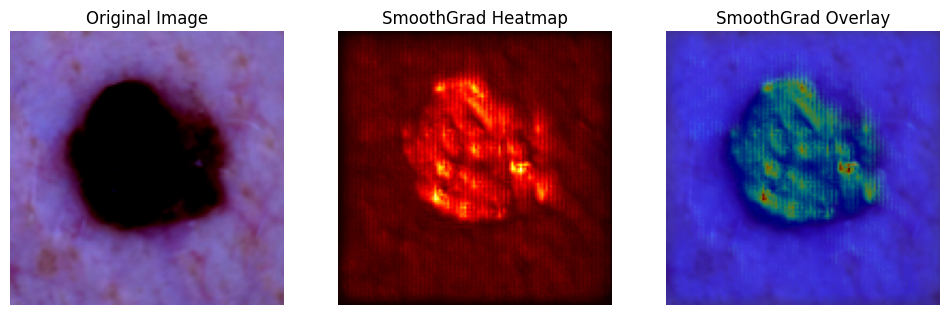

In [31]:
# Your solution here ...

saliency = Saliency(model)
nt = NoiseTunnel(saliency)
smooth_attr = nt.attribute(
    img,
    nt_type='smoothgrad',
    target=label,
    stdevs=0.2,
    nt_samples=200
)
smooth_attr = smooth_attr.squeeze().detach().cpu().numpy().max(axis=0)

show_heatmap(img, smooth_attr, "SmoothGrad")

- **Task (2 points)** GradCAM

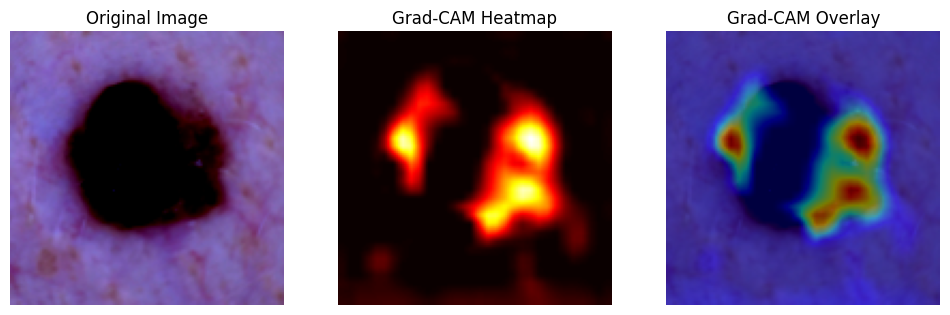

In [32]:
# Your solution here ...

layer_gc = LayerGradCam(model, model.conv3)
gradcam_attr = layer_gc.attribute(img, target=label)
gradcam_attr = F.relu(gradcam_attr)
gradcam_attr = F.interpolate(
    gradcam_attr,
    size=(img.shape[2], img.shape[3]),
    mode='bilinear',
    align_corners=False
)
gradcam_attr = gradcam_attr.squeeze().detach().cpu().numpy()
gradcam_attr = (gradcam_attr - gradcam_attr.min()) / (gradcam_attr.max() - gradcam_attr.min() + 1e-8)

show_heatmap(img, gradcam_attr, "Grad-CAM")

- **Task (2 points)** LRP (below with Captum)

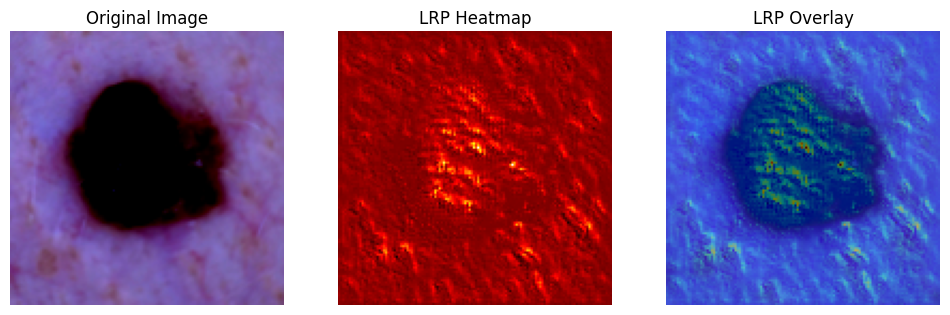

In [33]:
# Your solution here ...

lrp = LRP(model)
lrp_attr = lrp.attribute(img, target=label)
lrp_attr = lrp_attr.squeeze().detach().cpu().numpy().max(axis=0)

show_heatmap(img, lrp_attr, "LRP")

**Task (0.5 point)** Visualize the original image and all attribution maps side-by-side in a single figure

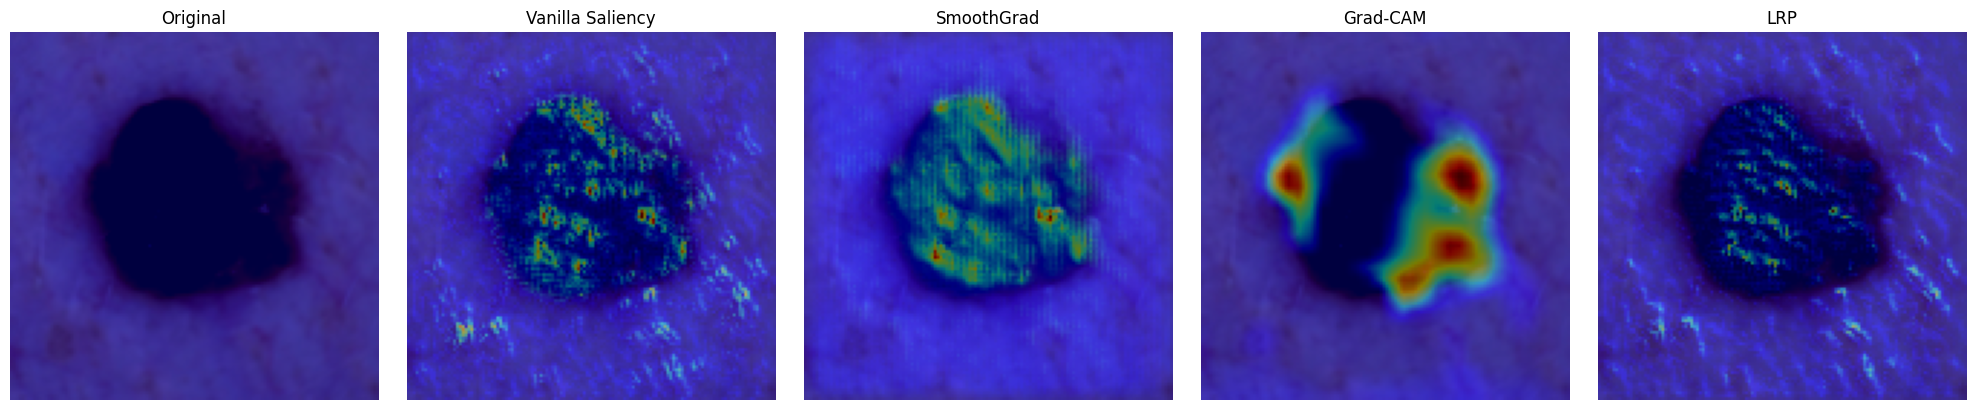

In [34]:
# Your solution here ...

def show_overlay(img, saliency, title):
    """
    Overlay saliency map on top of an image.
    img: tensor of shape (C,H,W) or (1,C,H,W)
    saliency: 2D numpy array of shape (H,W)
    """
    # If batch dimension exists, select first item
    if img.ndim == 4:
        img = img[0]

    if torch.is_tensor(img):
        img = img.detach().cpu().numpy()

    # Convert (C,H,W) -> (H,W,3) if RGB
    if img.ndim == 3:
        if img.shape[0] == 1:   # grayscale
            img = img[0]
        elif img.shape[0] == 3: # RGB
            img = img.transpose(1, 2, 0)

    plt.imshow(img, cmap='gray')
    plt.imshow(saliency, cmap='jet', alpha=0.5)
    plt.axis('off')
    plt.title(title)

def normalize(x):
    x = np.maximum(x, 0)
    x = x / (x.max() + 1e-8)
    return x

vanilla_map_norm    = normalize(vanilla_attr)
smoothgrad_map_norm = normalize(smooth_attr)
gradcam_map_norm    = normalize(gradcam_attr)
lrp_map_norm        = normalize(lrp_attr)

plt.figure(figsize=(20, 4))

# Original
plt.subplot(1, 5, 1)
show_overlay(img, np.zeros_like(vanilla_map_norm), "Original")

# Vanilla
plt.subplot(1, 5, 2)
show_overlay(img, vanilla_map_norm, "Vanilla Saliency")

# SmoothGrad
plt.subplot(1, 5, 3)
show_overlay(img, smoothgrad_map_norm, "SmoothGrad")

# Grad-CAM
plt.subplot(1, 5, 4)
show_overlay(img, gradcam_map_norm, "Grad-CAM")

# LRP
plt.subplot(1, 5, 5)
show_overlay(img, lrp_map_norm, "LRP")

plt.tight_layout()
plt.show()

**Task (1 point)** Identify two missclassified samples and compute all 4 attribution maps for each.


Sample 1 — Found misclassified: True=1, Pred=5


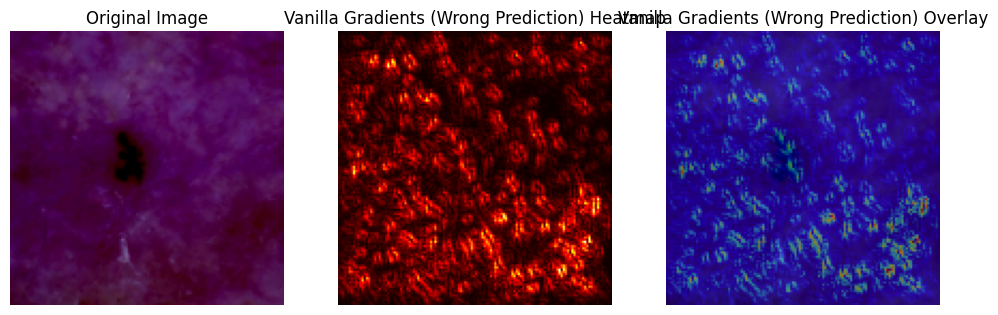

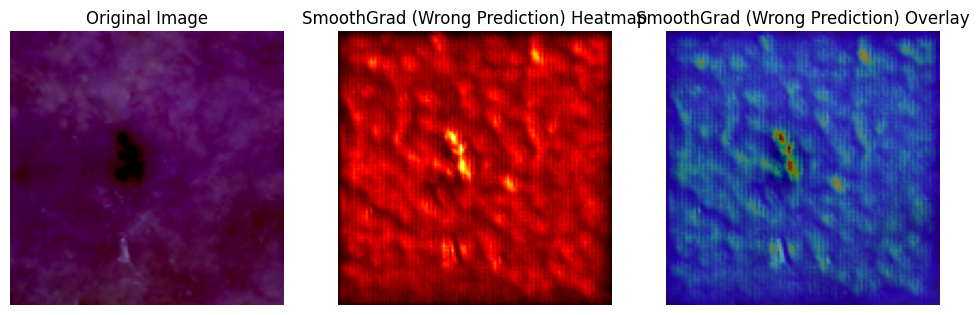

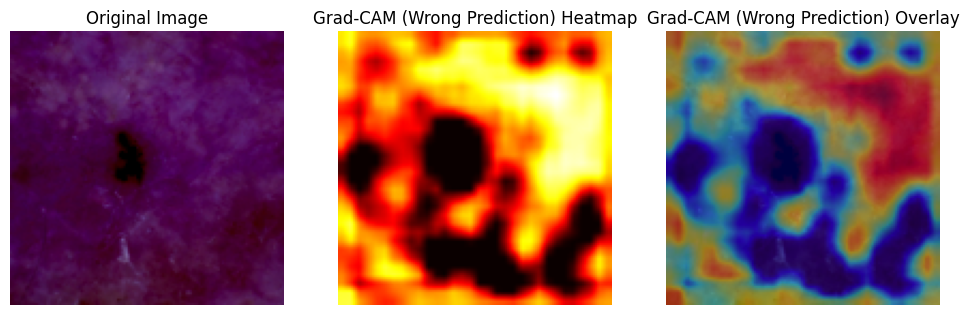

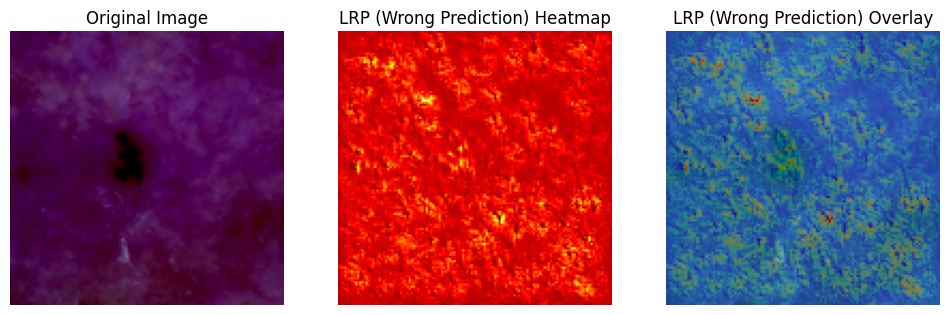


Sample 2 — Found misclassified: True=3, Pred=5


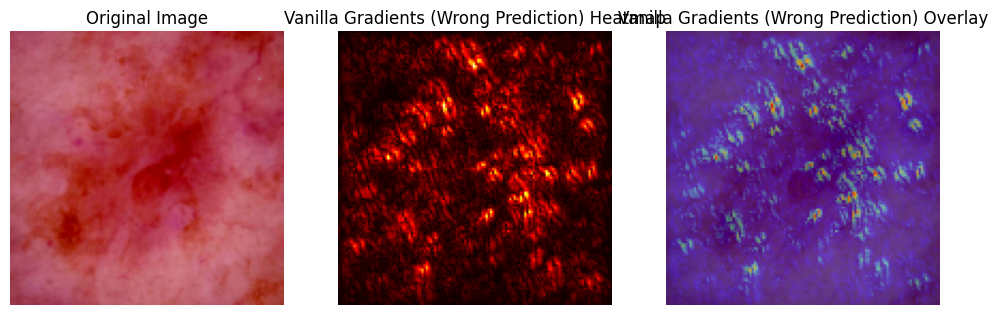

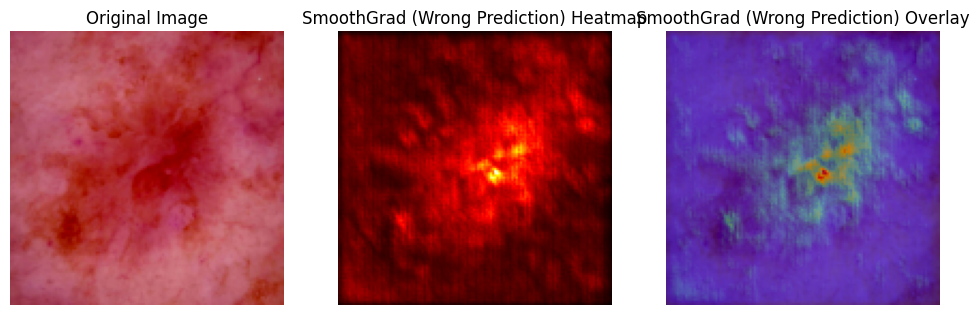

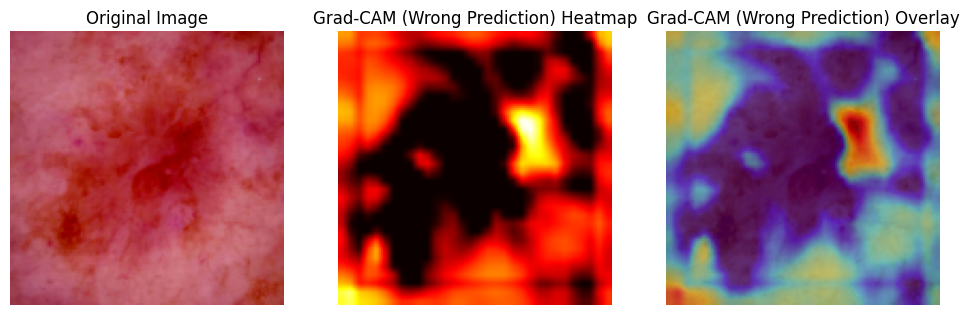

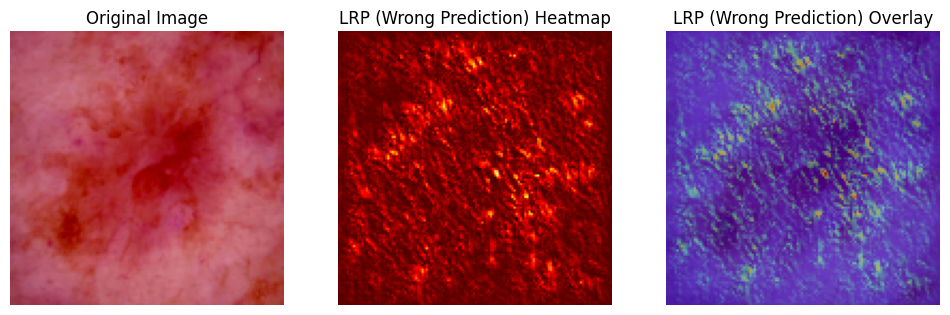

In [35]:
# Your solution here ...

import random
random.seed(42)

def get_random_misclassified(model, dataset):
    model.eval()
    misclassified = []

    # Collect all misclassified samples
    for i in range(len(dataset)):
        img, true_label = dataset[i]
        true_label = int(np.array(true_label).squeeze())
        img_cuda = img.unsqueeze(0).to(device)

        with torch.no_grad():
            pred_label = model(img_cuda).argmax().item()

        if pred_label != true_label:
            misclassified.append((i, img, true_label, pred_label))

    if len(misclassified) == 0:
        return None  # No misclassifications found

    # Pick one randomly
    return random.choice(misclassified)


# Run for two misclassified samples
for sample_num in range(2):
    idx, wrong_img, true_label, pred_label = get_random_misclassified(model, test_dataset)
    print(f"\nSample {sample_num+1} — Found misclassified: True={true_label}, Pred={pred_label}")

    wrong_img = wrong_img.unsqueeze(0).to(device)
    wrong_img.requires_grad = True

    # Vanilla Gradients
    saliency = Saliency(model)
    vanilla_attr = saliency.attribute(wrong_img, target=pred_label)
    vanilla_attr = vanilla_attr.squeeze().detach().cpu().numpy().max(axis=0)
    show_heatmap(wrong_img, vanilla_attr, "Vanilla Gradients (Wrong Prediction)")

    # SmoothGrad
    nt = NoiseTunnel(saliency)
    smooth_attr = nt.attribute(wrong_img, nt_type='smoothgrad',
                               target=pred_label, stdevs=0.2, nt_samples=200)
    smooth_attr = smooth_attr.squeeze().detach().cpu().numpy().max(axis=0)
    show_heatmap(wrong_img, smooth_attr, "SmoothGrad (Wrong Prediction)")

    # Grad-CAM
    layer_gc = LayerGradCam(model, model.conv3)
    gradcam_attr = layer_gc.attribute(wrong_img, target=pred_label)
    gradcam_attr = F.relu(gradcam_attr)
    gradcam_attr = F.interpolate(gradcam_attr, size=(wrong_img.shape[2], wrong_img.shape[3]),
                                 mode='bilinear', align_corners=False)
    gradcam_attr = gradcam_attr.squeeze().detach().cpu().numpy()
    gradcam_attr = (gradcam_attr - gradcam_attr.min()) / (gradcam_attr.max() - gradcam_attr.min() + 1e-8)
    show_heatmap(wrong_img, gradcam_attr, "Grad-CAM (Wrong Prediction)")

    # LRP
    lrp = LRP(model)
    lrp_attr = lrp.attribute(wrong_img, target=pred_label)
    lrp_attr = lrp_attr.squeeze().detach().cpu().numpy().max(axis=0)
    show_heatmap(wrong_img, lrp_attr, "LRP (Wrong Prediction)")

**Task (1 point)** Quantify how much each attrbution method focuses on the object vs background

Object region = central 50% (4096 / 16384 pixels = 25.00% of image)

Vanilla     : 0.427  (inside / total saliency)
SmoothGrad  : 0.425  (inside / total saliency)
Grad-CAM    : 0.686  (inside / total saliency)
LRP         : 0.357  (inside / total saliency)


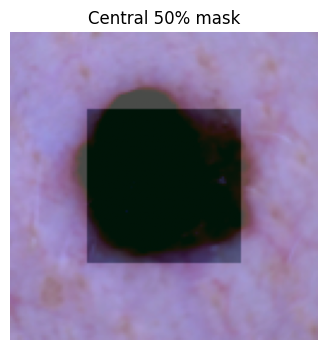

In [36]:
# Your solution here ...

H, W = img.shape[2], img.shape[3]

mask = np.zeros((H, W), dtype=bool)
h_start, h_end = H // 4, 3 * H // 4
w_start, w_end = W // 4, 3 * W // 4
mask[h_start:h_end, w_start:w_end] = True

# Put all normalized maps in a dict
saliency_maps = {
    'Vanilla':    vanilla_map_norm,
    'SmoothGrad': smoothgrad_map_norm,
    'Grad-CAM':   gradcam_map_norm,
    'LRP':        lrp_map_norm,
}

print(f"Object region = central 50% ({mask.sum()} / {H*W} pixels = "
      f"{mask.sum() / (H*W):.2%} of image)\n")

for name, m in saliency_maps.items():
    total = m.sum()
    inside = m[mask].sum()
    frac = inside / (total + 1e-8)
    print(f"{name:<12}: {frac:.3f}  (inside / total saliency)")

plt.figure(figsize=(4, 4))
plt.imshow(img.detach().cpu().squeeze().permute(1, 2, 0))
plt.imshow(mask, cmap='Greens', alpha=0.3)
plt.title("Central 50% mask")
plt.axis('off')
plt.show()
